#### Antrenarea modelului

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

df = pd.read_csv('../new_data.csv', index_col=False, low_memory=False)

encoders = {}
encoded_fields = ['specimen_part', 'formation', 'lithology1', 'environment', 'accepted_name']

for field in encoded_fields:
	encoder = LabelEncoder()
	df[field] = encoder.fit_transform(df[field])
	encoders[field] = encoder

scaled_fields = ['length', 'width', 'max_ma', 'min_ma', 'paleolng', 'paleolat']

minmax_scaler = MinMaxScaler()
df[scaled_fields] = minmax_scaler.fit_transform(df[scaled_fields])

standard_scaler = StandardScaler()
df[scaled_fields] = standard_scaler.fit_transform(df[scaled_fields])

X = df.drop(columns=['accepted_name'])
y = df['accepted_name']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)

model = RandomForestClassifier(n_estimators=50, max_depth=30, max_features='sqrt', n_jobs=-1, random_state=67)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7792


#### Matrice de confuzie

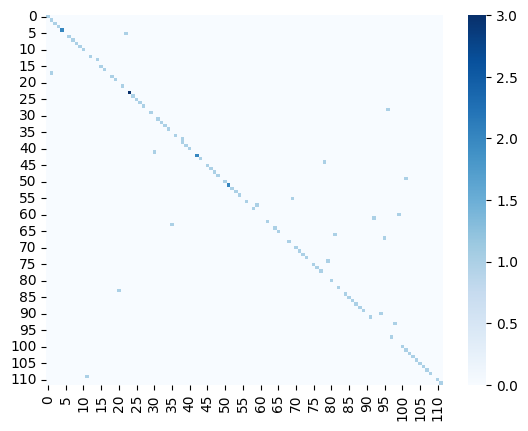

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test[0:100], y_pred[0:100])

sns.heatmap(cm, fmt='d', cmap='Blues')
plt.savefig("../graphs/confusion_matrix.png", bbox_inches="tight")

In [4]:
modelplus = {'model': model,
    'encoders': encoders,
    'minmax_scaler': minmax_scaler,
    'standard_scaler': standard_scaler,
    'feature_names': X.columns.tolist(),
	'confusion_matrix': cm
}
joblib.dump(modelplus, 'diego.pkl', compress=0)

['diego.pkl']